## Домашнее задание

### Задача 1
Примените алгоритм Metropolis для генерации выборки из распределения с плотностью
p(x) = 0.3N(-4, 2) + 0.7N(3, 6), где N(a, b) - плотность нормального распределения со средним a и дисперсией b. Для наглядности, ниже приведен график плотности смеси. Покажите, что гистограмма, построенная по выборке, приближает заданную плотность смеси.

In [42]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

weights = [0.3, 0.7]
means = [-4, 3]
variances = [2, 6]


In [43]:
def p(x):
    return (
        weights[0] * norm(means[0], np.sqrt(variances[0])).pdf(x) +
        weights[1] * norm(means[1], np.sqrt(variances[1])).pdf(x)
    )


In [44]:
def metropolis(x0, p, q, n, std=1.0):
    x = x0
    samples = [x]

    for _ in range(n - 1):
        x_new = q(x, std)
        alpha = p(x_new) / p(x)

        if np.random.rand() < alpha:
            x = x_new

        samples.append(x)

    return samples

def q(x, std):
    return x + std * np.random.randn()


In [57]:
n_samples = 3000
x_start = 0
std_dev = 3.0

samples = metropolis(x0=x_start, p=p, q=q, n=n_samples, std=std_dev)


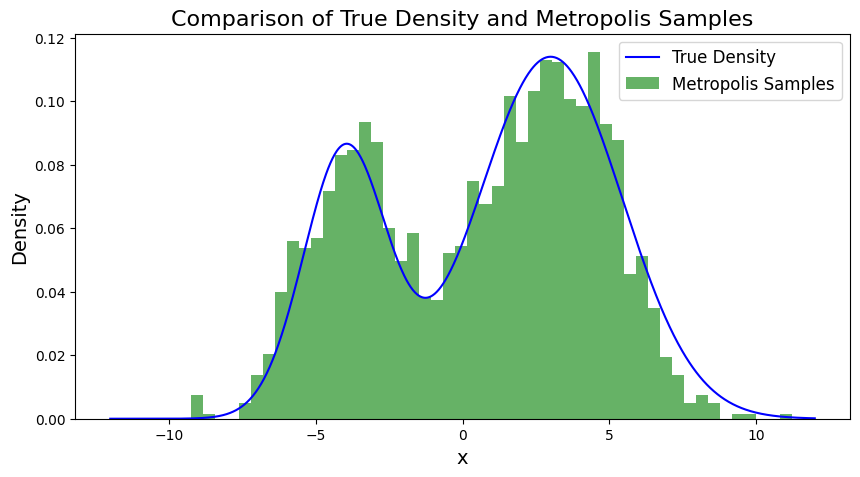

In [59]:
x = np.linspace(-12, 12, 1000)
true_density = p(x)

plt.figure(figsize=(10, 5))
plt.plot(x, true_density, label="True Density", color="blue")
plt.hist(samples, bins=50, density=True, alpha=0.6, label="Metropolis Samples", color="green")
plt.legend(fontsize=12)
plt.xlabel("x", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.title("Comparison of True Density and Metropolis Samples", fontsize=16)
plt.show()

### Задача 2
Рассмотрим граф $G=(V,E)$, вершинам которого случайным образом приписаны значения 0 и 1 так, что смежные вершины не могут одновременно иметь значение 1. Пример допустимой расстановки значений по вершинам графа показан на картинке ниже (черные вершины имеют значение 1, белые - 0):

<!-- ![img](http://www.mathematik.uni-ulm.de/stochastik/lehre/ss06/markov/skript_engl/bild4.jpg) -->

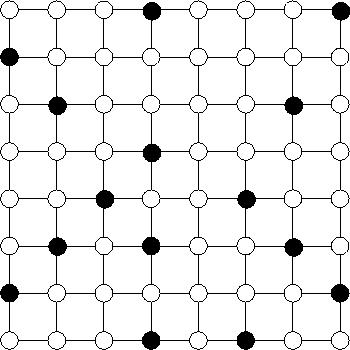

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def mcmc_step(graph, i, j, p=0.5):
    if graph[i, j] == 0:
        if graph[i - 1, j] != 1 and graph[i + 1, j] != 1 and graph[i, j - 1] != 1 and graph[i, j + 1] != 1:
            if np.random.rand() < p:
                graph[i, j] = 1
    elif graph[i, j] == 1:
        if np.random.rand() < p:
            graph[i, j] = 0

def mcmc_simulation(graph_size, steps, p=0.5):
    graph = np.zeros((graph_size + 2, graph_size + 2))
    weights = []

    for _ in range(steps):
        i, j = np.random.randint(1, graph_size + 1), np.random.randint(1, graph_size + 1)
        mcmc_step(graph, i, j, p)
        weights.append(graph.sum())

    return graph, weights


In [35]:
graph_size_2x2 = 2
steps_2x2 = 100000
burn_in_2x2 = 20000
thinning_2x2 = 100

_, weights_2x2 = mcmc_simulation(graph_size_2x2, steps_2x2)

result_2x2 = np.mean(weights_2x2[burn_in_2x2::thinning_2x2])
print(f"Expected value for 2x2 graph: {result_2x2:.6f} (should be close to 8/7 ≈ {8/7:.6f})")


Expected value for 2x2 graph: 1.138750 (should be close to 8/7 ≈ 1.142857)


In [38]:
graph_size_10x10 = 10
steps_10x10 = 100000

_, weights_10x10 = mcmc_simulation(graph_size_10x10, steps_10x10)

burn_in_10x10 = 5000
thinning_10x10 = 400
result_10x10 = np.mean(weights_10x10[burn_in_10x10::thinning_10x10])
print(f"Expected value for 10x10 graph: {result_10x10:.2f}")


Expected value for 10x10 graph: 23.42


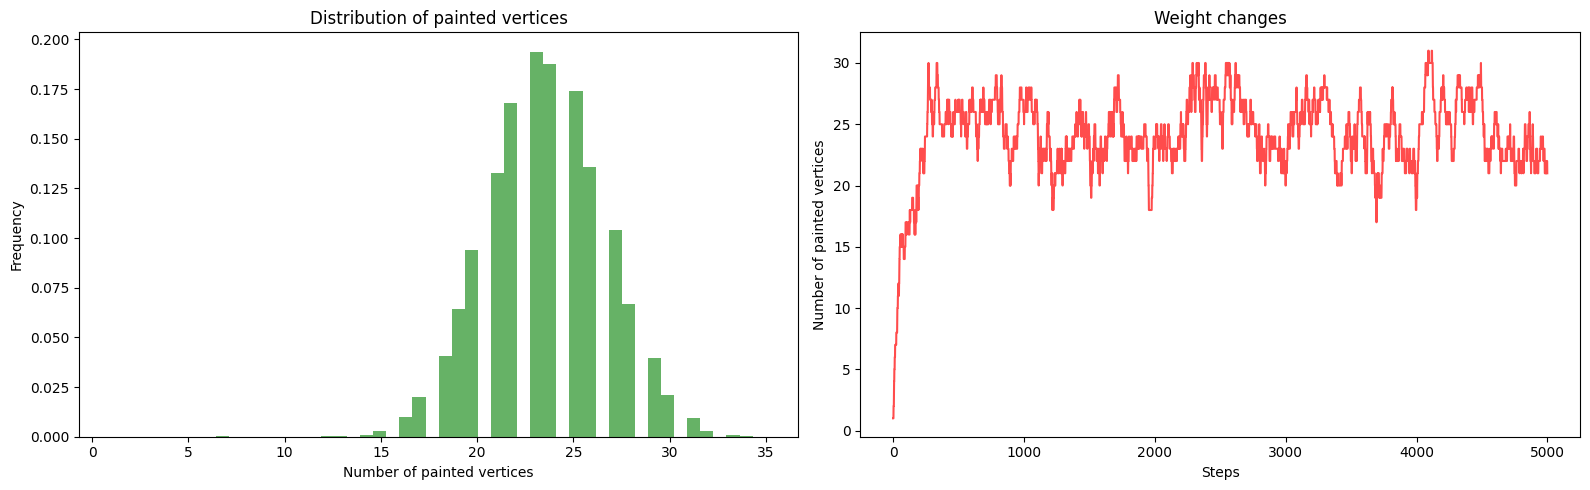

In [41]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))
axs[0].hist(weights_10x10, bins=50, density=True, color='green', alpha=0.6)
axs[0].set_xlabel("Number of painted vertices")
axs[0].set_ylabel("Frequency")
axs[0].set_title(f"Distribution of painted vertices")

axs[1].plot(weights_10x10[:5000], color='red', alpha=0.7)
axs[1].set_xlabel("Steps")
axs[1].set_ylabel("Number of painted vertices")
axs[1].set_title(f"Weight changes")

plt.tight_layout()
plt.show()


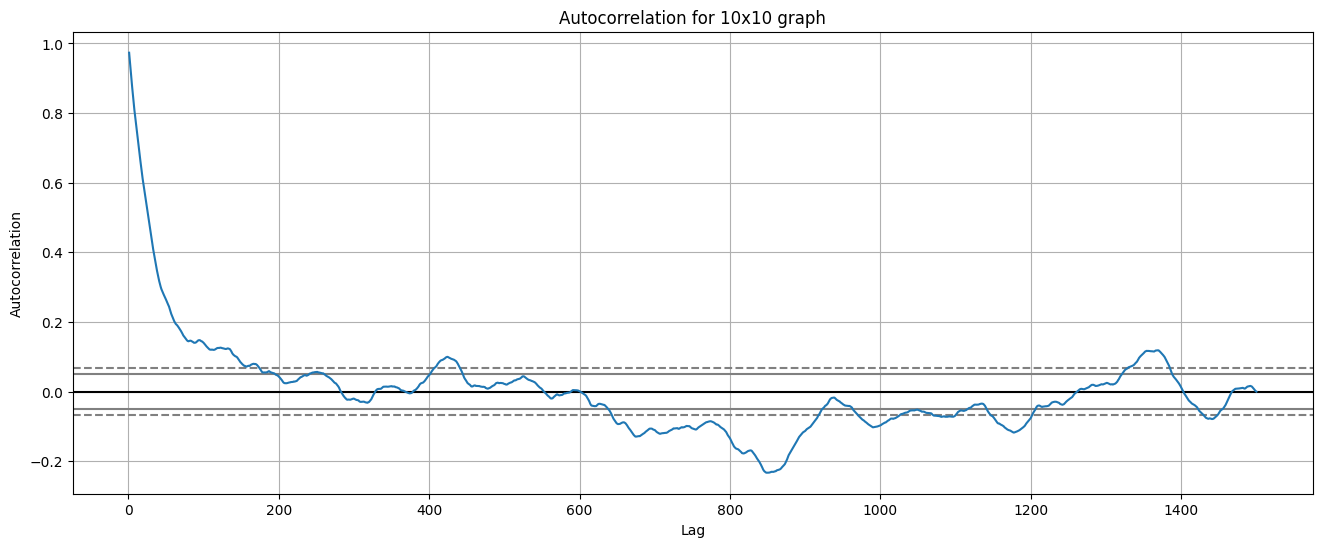

In [32]:
fig, ax = plt.subplots(1, figsize=(16, 6))
pd.plotting.autocorrelation_plot(pd.Series(weights_10x10[:1500]), ax=ax)
ax.set_title("Autocorrelation for 10x10 graph")
plt.show()
